In [2]:
# Import Libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load Dataset
df = pd.read_csv("return_prediction_data.csv")

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Customer_ID,Product_ID,Store_ID,Unit_Price,Quantity,Amount,Currency,Months,Weekdays,Payment_Method,...,Total_Cust_Return,Cust_Return_Rate,Total_Cust_Spent,Avg_Cust_Spend,Total_Prod_Txn,Total_Prod_Return,Prod_Return_Rate,Total_Store_Txn,Total_Store_Return,Store_Return_Rate
0,47162,485,1,80.5,1,80.5,USD,1,6,1,...,0,0.00000,429.10,42.91,111,3,0.02703,477743,25282,0.05292
1,47162,2779,1,31.5,1,18.9,USD,1,6,1,...,0,0.00000,429.10,42.91,78,5,0.06410,477743,25282,0.05292
2,47162,64,1,45.5,1,27.3,USD,1,6,1,...,0,0.00000,429.10,42.91,171,11,0.06433,477743,25282,0.05292
3,10142,131,1,70.0,1,42.0,USD,1,6,1,...,1,0.07692,419.83,32.29,167,8,0.04790,477743,25282,0.05292
4,10142,716,1,26.0,1,26.0,USD,1,6,1,...,1,0.07692,419.83,32.29,133,9,0.06767,477743,25282,0.05292


In [4]:
# Inspect Dataset
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599999 entries, 0 to 599998
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer_ID         599999 non-null  int64  
 1   Product_ID          599999 non-null  int64  
 2   Store_ID            599999 non-null  int64  
 3   Unit_Price          599999 non-null  float64
 4   Quantity            599999 non-null  int64  
 5   Amount              599999 non-null  float64
 6   Currency            599999 non-null  object 
 7   Months              599999 non-null  int64  
 8   Weekdays            599999 non-null  int64  
 9   Payment_Method      599999 non-null  int64  
 10  Is_Discounted       599999 non-null  int64  
 11  Is_Return           599999 non-null  int64  
 12  Total_Cust_Txn      599999 non-null  int64  
 13  Total_Cust_Return   599999 non-null  int64  
 14  Cust_Return_Rate    599999 non-null  float64
 15  Total_Cust_Spent    599999 non-nul

,Customer_ID,Product_ID,Store_ID,Unit_Price,Quantity,Amount,Currency,Months,Weekdays,Payment_Method,...,Total_Cust_Return,Cust_Return_Rate,Total_Cust_Spent,Avg_Cust_Spend,Total_Prod_Txn,Total_Prod_Return,Prod_Return_Rate,Total_Store_Txn,Total_Store_Return,Store_Return_Rate
count,5.999990e+05,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999,599999.000000,599999.000000,599999.000000,...,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000,599999.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,USD,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,599999,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,6.888774e+04,8268.719015,1.203760,50.995712,1.099822,49.957036,NaN,6.518218,3.480026,0.199745,...,0.749176,0.053027,528.501996,50.093693,530.890218,28.119845,0.053009,473408.813816,25109.822513,0.053044
std,9.258995e+04,4180.040026,0.402793,26.769801,0.395644,36.127998,NaN,3.782619,2.111490,0.399809,...,1.666842,0.100708,389.184290,17.850898,252.478634,14.383600,0.012971,8567.813419,340.360225,0.000246
min,1.000000e+00,1.000000,1.000000,4.000000,1.000000,2.400000,NaN,1.000000,0.000000,0.000000,...,0.000000,0.000000,3.000000,3.000000,9.000000,0.000000,0.000000,456472.000000,24437.000000,0.052920
25%,2.257700e+04,4864.000000,1.000000,32.000000,1.000000,27.000000,NaN,3.000000,2.000000,0.000000,...,0.000000,0.000000,245.390000,40.110000,374.000000,18.000000,0.045660,477743.000000,25282.000000,0.052920
50%,4.468400e+04,7755.000000,1.000000,44.500000,1.000000,40.500000,NaN,6.000000,4.000000,0.000000,...,0.000000,0.000000,439.230000,47.950000,504.000000,28.000000,0.052630,477743.000000,25282.000000,0.052920
75%,8.681000e+04,12236.000000,1.000000,63.500000,1.000000,61.000000,NaN,10.000000,5.000000,0.000000,...,1.000000,0.076920,720.300000,56.900000,771.000000,40.000000,0.060000,477743.000000,25282.000000,0.052920


In [5]:
# Remove leading and trailing spaces from column names to ensure consistency
df.columns = df.columns.str.strip()

In [6]:
# Identify all duplicate rows in the DataFrame (including all occurrences)
dups = df[df.duplicated(keep=False)]

# Count the frequency of each duplicate row
dups_count = dups.value_counts().reset_index(name='count')

# Display the top 20 most frequently duplicated rows
dups_count.sort_values('count', ascending=False).head(20)

,Customer_ID,Product_ID,Store_ID,Unit_Price,Quantity,Amount,Currency,Months,Weekdays,Payment_Method,...,Cust_Return_Rate,Total_Cust_Spent,Avg_Cust_Spend,Total_Prod_Txn,Total_Prod_Return,Prod_Return_Rate,Total_Store_Txn,Total_Store_Return,Store_Return_Rate,count
0,10050,16384,1,66.5,1,66.50,USD,3,6,0,...,0.42308,1527.25,58.74,78,4,0.05128,477743,25282,0.05292,3
1,1323,4635,1,36.5,1,36.50,USD,6,3,0,...,0.30000,485.00,48.50,483,28,0.05797,477743,25282,0.05292,3
2,10792,12080,1,80.5,1,80.50,USD,12,0,0,...,0.50000,1105.62,110.56,912,54,0.05921,477743,25282,0.05292,3
3,61198,8170,1,63.0,3,94.50,USD,12,5,0,...,0.53333,828.75,55.25,666,41,0.06156,477743,25282,0.05292,3
4,90123,8711,2,70.0,1,70.00,USD,9,1,0,...,0.23077,1281.25,49.28,797,42,0.05270,456472,24437,0.05353,3
5,284354,3857,2,55.0,1,55.00,USD,7,6,1,...,0.70270,2156.63,58.29,425,19,0.04471,456472,24437,0.05353,3
6,284354,3914,2,58.0,1,58.00,USD,7,6,1,...,0.70270,2156.63,58.29,585,37,0.06325,456472,24437,0.05353,3
7,284354,5082,2,61.0,1,61.00,USD,7,6,1,...,0.70270,2156.63,58.29,431,31,0.07193,456472,24437,0.05353,3
8,284354,5344,2,27.0,3,81.00,USD,7,6,1,...,0.70270,2156.63,58.29,564,38,0.06738,456472,24437,0.05353,3
9,2122,6246,1,46.5,1,23.25,USD,12,3,0,...,0.00000,218.75,31.25,683,31,0.04539,477743,25282,0.05292,2


In [7]:
# Remove duplicate rows from the DataFrame, keeping the first occurrence
df = df.drop_duplicates()

In [8]:
# Check Target Variable
TARGET = "Is_Return"   # <-- update if needed

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found!")

df[TARGET] = df[TARGET].astype(int)
df[TARGET].value_counts()


Is_Return
0    568092
1     31277
Name: count, dtype: int64

In [13]:
# Separate features (X) and target variable (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify numerical and categorical feature columns for preprocessing
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Display lists of numerical and categorical features
numeric_features, categorical_features

(['Customer_ID',
  'Product_ID',
  'Store_ID',
  'Unit_Price',
  'Quantity',
  'Amount',
  'Months',
  'Weekdays',
  'Payment_Method',
  'Is_Discounted',
  'Total_Cust_Txn',
  'Total_Cust_Return',
  'Cust_Return_Rate',
  'Total_Cust_Spent',
  'Avg_Cust_Spend',
  'Total_Prod_Txn',
  'Total_Prod_Return',
  'Prod_Return_Rate',
  'Total_Store_Txn',
  'Total_Store_Return',
  'Store_Return_Rate'],
 ['Currency'])

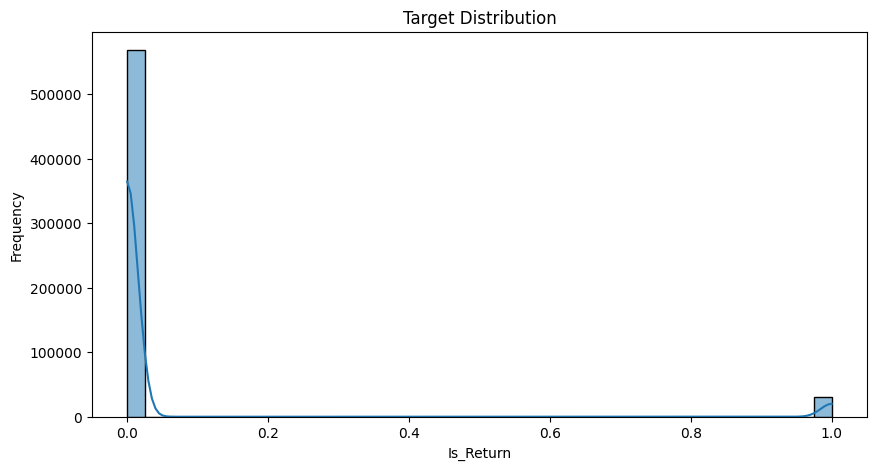

In [11]:
# ----- Target Distribution -----
plt.figure(figsize=(10,5))
sns.histplot(df[TARGET], kde=True, bins=40)
plt.title("Target Distribution")
plt.xlabel(TARGET)
plt.ylabel("Frequency")
plt.show()

In [14]:
# Build Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


In [15]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


🔹 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98    113625
           1       0.62      0.26      0.37      6249

    accuracy                           0.95    119874
   macro avg       0.79      0.63      0.67    119874
weighted avg       0.94      0.95      0.94    119874

ROC-AUC Score: 0.9401548097200504


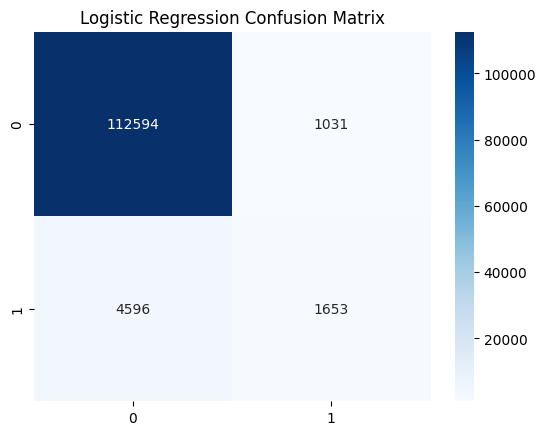

In [16]:
# Logistic Regression Model
log_reg_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=500))
])

log_reg_model.fit(X_train, y_train)

y_pred_lr = log_reg_model.predict(X_test)

print("🔹 Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("ROC-AUC Score:", roc_auc_score(y_test, log_reg_model.predict_proba(X_test)[:,1]))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [19]:
# example
example = pd.DataFrame([{
    "Customer_ID": 4328,
    "Product_ID": 250,
    "Store_ID": 11,
    "Unit_Price": 11.99,
    "Quantity": 4,
    "Amount": 50.98,
    "Months": 6,
    "Weekdays": 4,
    "Payment_Method": 1,
    "Is_Discounted": 0,
    "Total_Cust_Txn": 45,
    "Total_Cust_Return": 2,
    "Cust_Return_Rate": 0.065,
    "Total_Cust_Spent": 500,
    "Avg_Cust_Spend": 40,
    "Total_Prod_Txn": 250,
    "Total_Prod_Return": 7,
    "Prod_Return_Rate": 0.022,
    "Total_Store_Txn": 700,
    "Total_Store_Return": 30,
    "Store_Return_Rate": 0.08,
    "Currency": "USD"     # categorical
}])

prob = log_reg_model.predict_proba(example)[:, 1][0]
print("Probability of Return:", prob)

# Predict class (0 = No Return, 1 = Return)
pred_class = log_reg_model.predict(example)[0]
print("Predicted Class:", pred_class)

Probability of Return: 0.9777437569060933
Predicted Class: 1


🔹 Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97    113625
           1       0.33      0.22      0.26      6249

    accuracy                           0.94    119874
   macro avg       0.64      0.60      0.61    119874
weighted avg       0.93      0.94      0.93    119874

ROC-AUC Score: 0.9216232631104366


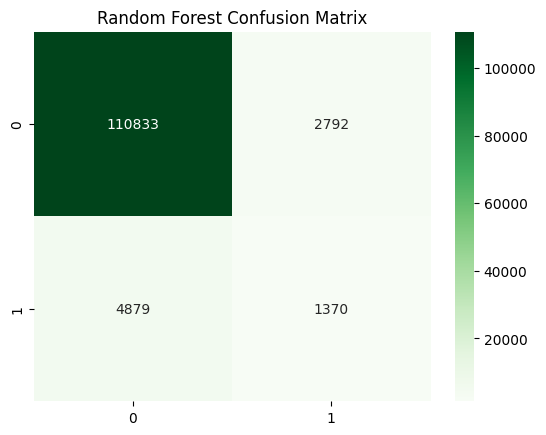

In [20]:
# Random Forest Model
rf_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("🔹 Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC Score:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()


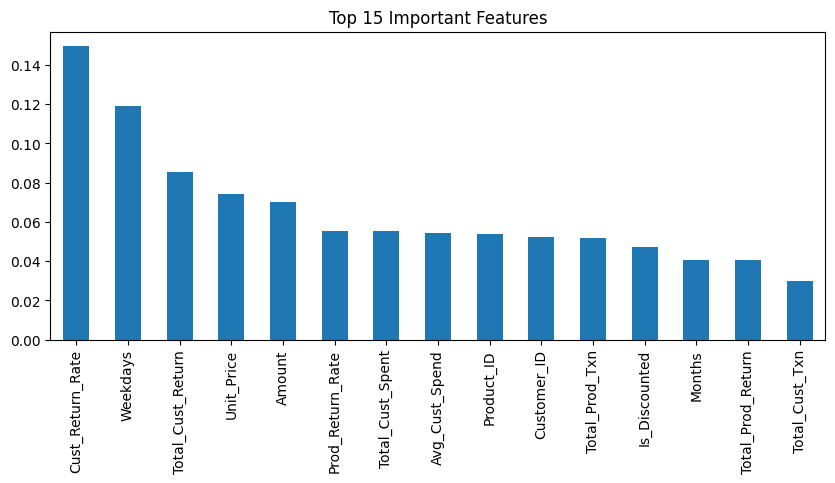

In [21]:
# Feature Importance (Random Forest)
rf = rf_model.named_steps['model']
ohe = rf_model.named_steps['preprocess'].named_transformers_['cat']
ohe_features = ohe.get_feature_names_out(categorical_features)
all_features = numeric_features + list(ohe_features)

importances = pd.Series(rf.feature_importances_, index=all_features)
importances.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(10,4))
plt.title("Top 15 Important Features")
plt.show()


2. Monthly Demand Forecasting

In [22]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.exponential_smoothing.ets import ETSModel


In [32]:
# Load Dataset
df = pd.read_csv("Monthly Demand Forecasting.csv")  # Update path

# Clean column
df['Months'] = df['Months'].astype(str).str.strip()
df['Month'] = pd.to_datetime(df['Months'], errors='coerce')
df = df.dropna(subset=['Month'])

# Aggregate total units sold
df_ag = df.groupby(['Month','Category','Country'])['Total_Units_Sold'].sum().reset_index()

# Sort by Month
df_ag = df_ag.sort_values('Month').reset_index(drop=True)

# Encode Month numerically for Gradient Boosting
df_ag['Month_num'] = df_ag['Month'].dt.year*12 + df_ag['Month'].dt.month

df.head()

,Category,Country,Months,Total_Units_Sold,Total_Sales,Avg_Unit_Price,Avg_Effective_Price,Avg_Discount,Total_Discounted_Transactions,Total_Transactions,Month
0,Children,Deutschland,2023-01-01,3262,74740.420,29.241,22.942,0.189,1407,2978,2023-01-01
1,Children,Deutschland,2023-02-01,1525,38311.150,25.400,25.400,0.000,0,1355,2023-02-01
2,Children,Deutschland,2023-03-01,5606,179670.151,41.382,32.182,0.201,2915,5088,2023-03-01
3,Children,Deutschland,2023-04-01,2649,98858.500,37.227,37.227,0.000,0,2403,2023-04-01
4,Children,Deutschland,2023-05-01,4800,139982.875,33.831,29.224,0.148,2570,4334,2023-05-01


In [45]:
# SARIMA Model
sarima_p = []

for cat in df_ag['Category'].unique():
    for country in df_ag['Country'].unique():
        ts = df_ag[(df_ag['Category']==cat) & (df_ag['Country']==country)]
        ts = ts.set_index('Month').asfreq('MS')['Total_Units_Sold']
        
        if ts.shape[0] < 12:
            continue

        # last 6 months as test
        split_date = ts.index.max() - pd.DateOffset(months=6)
        ts_train = ts[ts.index <= split_date]
        ts_test = ts[ts.index > split_date]

        # SARIMA
        model = SARIMAX(ts_train, order=(1,1,1), seasonal_order=(1,1,1,12),
                        enforce_stationarity=False, enforce_invertibility=False)
        model_fit = model.fit(disp=False)

        # Forecast
        forecast = model_fit.get_forecast(len(ts_test))
        pred_mean = forecast.predicted_mean

        sarima_p.append(pd.DataFrame({
            'Month': ts_test.index,
            'Category': cat,
            'Country': country,
            'SARIMA_P': pred_mean.values,
            'Actual': ts_test.values
        }))

sarima_df = pd.concat(sarima_p).reset_index(drop=True)
sarima_df.head()

,Month,Category,Country,SARIMA_P,Actual
0,2024-10-01,Children,Deutschland,6355.958346,5069
1,2024-11-01,Children,Deutschland,3968.079239,2733
2,2024-12-01,Children,Deutschland,10075.269368,10120
3,2025-01-01,Children,Deutschland,4343.717568,3301
4,2025-02-01,Children,Deutschland,3085.671355,1482


In [36]:
# Sort data by category, country, and time to ensure correct temporal order
df_ag = df_ag.sort_values(['Category','Country','Month'])

# Lag features
df_ag['Lag1'] = df_ag.groupby(['Category','Country'])['Total_Units_Sold'].shift(1)
df_ag['Lag2'] = df_ag.groupby(['Category','Country'])['Total_Units_Sold'].shift(2)

# Create rolling mean features to capture short- and long-term trends
df_ag['Rolling3'] = df_ag.groupby(['Category','Country'])['Total_Units_Sold'].shift(1).rolling(3).mean()
df_ag['Rolling6'] = df_ag.groupby(['Category','Country'])['Total_Units_Sold'].shift(1).rolling(6).mean()
df_ag['Rolling12'] = df_ag.groupby(['Category','Country'])['Total_Units_Sold'].shift(1).rolling(12).mean()

# Replace missing values caused by lagging and rolling calculations with zeros
df_ag[['Lag1','Lag2','Rolling3','Rolling6','Rolling12']] = df_ag[['Lag1','Lag2','Rolling3','Rolling6','Rolling12']].fillna(0)

# Normalize month number to capture time progression as a continuous feature
month_min = df_ag['Month_num'].min()
month_max = df_ag['Month_num'].max()
df_ag['Month_num_norm'] = (df_ag['Month_num'] - month_min) / (month_max - month_min)

# Extract month of year to model seasonality
df_ag['Month_of_year'] = df_ag['Month'].dt.month.astype(str)

In [37]:
# Define a time-based split: use all data except the last 6 months for training
split_date = df_ag['Month'].max() - pd.DateOffset(months=6)

# Split the dataset into training and testing sets based on time
df_train = df_ag[df_ag['Month'] <= split_date].copy()
df_test = df_ag[df_ag['Month'] > split_date].copy()

# Select feature columns for the model
feature_cols = ['Category','Country','Month_num_norm','Lag1','Lag2','Rolling3','Rolling6','Rolling12','Month_of_year']

# Separate features and target variable
X_train = df_train[feature_cols]
y_train = df_train['Total_Units_Sold']
X_test = df_test[feature_cols]
y_test = df_test['Total_Units_Sold']

# Apply log transformation to the target variable to stabilize variance and reduce skewness
y_train_log = np.log1p(y_train)

In [38]:
# Gradient Boosting Regression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Category','Country','Month_of_year']),
    ('num', 'passthrough', ['Month_num_norm','Lag1','Lag2','Rolling3','Rolling6','Rolling12'])
])

gb_model = Pipeline([
    ('preprocess', preprocessor),
    ('model', GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        min_samples_split=5,
        min_samples_leaf=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train_log)

df_test['GBR_P'] = np.expm1(gb_model.predict(X_test))

# Check results
df_test[['Month','Category','Country','Total_Units_Sold','GBR_P']].head(10)

,Month,Category,Country,Total_Units_Sold,GBR_P
453,2024-10-01,Children,Deutschland,5069,4594.045115
481,2024-11-01,Children,Deutschland,2733,2696.485347
495,2024-12-01,Children,Deutschland,10120,9644.567743
520,2025-01-01,Children,Deutschland,3301,3843.650028
544,2025-02-01,Children,Deutschland,1482,1975.053893
563,2025-03-01,Children,Deutschland,2453,7401.838494
454,2024-10-01,Children,España,4482,3736.715195
480,2024-11-01,Children,España,2157,2208.967774
496,2024-12-01,Children,España,7653,7403.540387
516,2025-01-01,Children,España,2282,2439.331450


In [50]:
# Merge SARIMA predictions with Gradient Boosting predictions for comparison
comparison_df = sarima_df.merge(
    df_test[['Month','Category','Country','GBR_P']],
    on=['Month','Category','Country'], how='left'
)
# Preview the combined comparison table
comparison_df.head()

,Month,Category,Country,SARIMA_P,Actual,GBR_P
0,2024-10-01,Children,Deutschland,6355.958346,5069,4594.045115
1,2024-11-01,Children,Deutschland,3968.079239,2733,2696.485347
2,2024-12-01,Children,Deutschland,10075.269368,10120,9644.567743
3,2025-01-01,Children,Deutschland,4343.717568,3301,3843.650028
4,2025-02-01,Children,Deutschland,3085.671355,1482,1975.053893


<Figure size 1200x600 with 0 Axes>

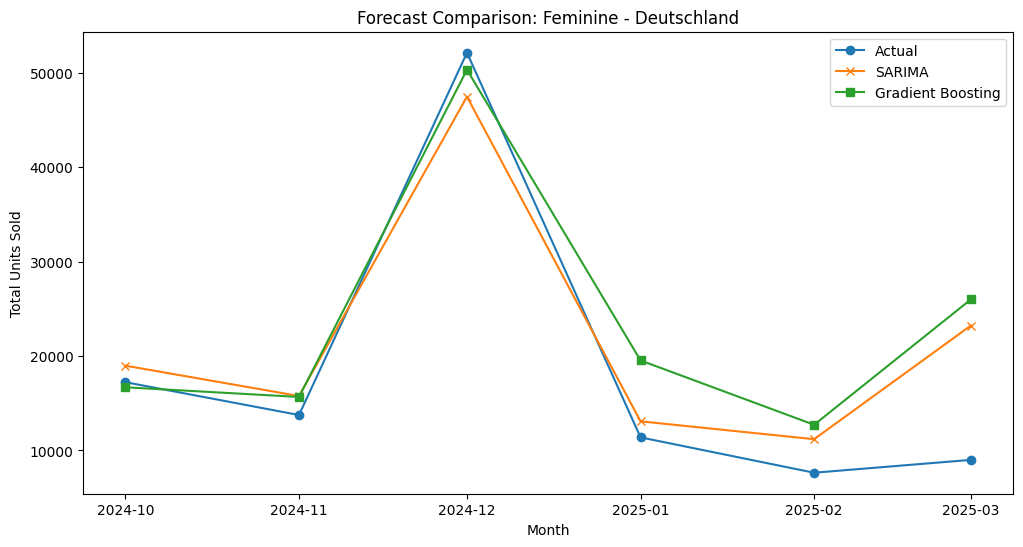

In [51]:
# Plot Forecast vs Actual
plt.figure(figsize=(12,6))

example = comparison_df[(comparison_df['Category']=='Feminine') & 
                        (comparison_df['Country']=='Deutschland')]

plt.figure(figsize=(12,6))
plt.plot(example['Month'], example['Actual'], label='Actual', marker='o')
plt.plot(example['Month'], example['SARIMA_P'], label='SARIMA', marker='x')
plt.plot(example['Month'], example['GBR_P'], label='Gradient Boosting', marker='s')
plt.title('Forecast Comparison: Feminine - Deutschland')
plt.xlabel('Month')
plt.ylabel('Total Units Sold')
plt.legend()
plt.show()

In [52]:
# Compare Results
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import numpy as np

# SARIMA metrics
sarima_mape = mean_absolute_percentage_error(comparison_df['Actual'], comparison_df['SARIMA_P'])
sarima_rmse = np.sqrt(mean_squared_error(comparison_df['Actual'], comparison_df['SARIMA_P']))

# Gradient Boosting metrics
gbr_mape = mean_absolute_percentage_error(comparison_df['Actual'], comparison_df['GBR_P'])
gbr_rmse = np.sqrt(mean_squared_error(comparison_df['Actual'], comparison_df['GBR_P']))

print(f"SARIMA: MAPE={sarima_mape:.4f}, RMSE={sarima_rmse:.2f}")
print(f"Gradient Boosting: MAPE={gbr_mape:.4f}, RMSE={gbr_rmse:.2f}")


SARIMA: MAPE=0.5853, RMSE=6730.45
Gradient Boosting: MAPE=0.3834, RMSE=5421.11


In [57]:
# Final Forecast
final_model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,13)).fit()

future_forecast = final_model.forecast(10)
future_forecast

2025-04-01    44853.478406
2025-05-01    52691.314913
2025-06-01    44486.517016
2025-07-01    45281.466659
2025-08-01    41035.412171
2025-09-01    40783.015533
2025-10-01    45626.860680
2025-11-01    58594.728414
2025-12-01    56889.968367
2026-01-01    60706.617986
Freq: MS, Name: predicted_mean, dtype: float64

1. Return Prediction – Evaluation Results

   
Model 1. Logistic Regression 

Overall Performance Metrics
- Accuracy: 0.95
- Macro Average F1-score: 0.68
- Weighted Average F1-score: 0.94

Interpretation of Results
- The Logistic Regression model demonstrates excellent performance on the majority class (No Return), correctly identifying most non-return transactions.
- The high accuracy (95%) and weighted F1-score (0.94) indicate strong overall predictive capability; however, these metrics are influenced by the dominance of the majority class.
- For return cases (minority class), the model shows moderate precision but low recall, meaning:
    - When the model predicts a return, it is often correct.
    - However, a large number of actual return cases are missed, limiting effectiveness for proactive return prevention.
- This behavior suggests the model is conservative, prioritizing correctness over coverage for return predictions.



Model 2: Random Forest – Evaluation Results


Overall Performance Metrics

- Accuracy: 0.94
- Macro Average F1-score: 0.61
- Weighted Average F1-score: 0.93
- ROC–AUC Score: 0.92

Interpretation of Results

- The Random Forest model demonstrates strong predictive performance for the majority class (No Return), with high precision (0.96) and recall (0.98), ensuring most non-return transactions are correctly classified.
- The overall accuracy of 94% and weighted F1-score of 0.93 indicate good general performance; however, these metrics are influenced by the class imbalance in the dataset.
- For return cases (minority class), the model exhibits low recall (0.22) and low F1-score (0.26), meaning:
    - A significant number of actual return cases are not detected.
    - The model is even more conservative than Logistic Regression in predicting returns.
- The ROC–AUC score of 0.92 suggests that the model has strong discriminatory ability, but this does not fully translate into effective minority class detection.

Monthly Demand Forecasting – Evaluation Results

Model                Mape         RSME
SARIMA               58.53%       6730.45
Gradient Boosting    38.34%       54211.11

Interpretation of Results


SARIMA Model

- The SARIMA model captures seasonal patterns and trend components in monthly demand.
- However, the high MAPE (58.53%) indicates poor percentage-based forecasting accuracy.
- The higher RMSE suggests large deviations between predicted and actual monthly demand.
- SARIMA struggles to adapt to non-linear demand fluctuations and external influences.


Gradient Boosting Model

- Gradient Boosting significantly outperforms SARIMA across both metrics.
- A lower MAPE (38.34%) indicates more accurate relative demand forecasts.
- The lower RMSE (5,421.11) shows reduced absolute forecasting error.
- The model effectively captures complex, non-linear relationships between demand and explanatory features such as price, discounts, and transaction volume.
